# Can two identical emitter types be told apart?

Every synthetic emitter sends **QPSK**. Only its fixed hardware imperfections differ. We compare a conventional real CNN (I and Q as two channels) with a similarly sized complex CNN that processes IQ natively.

| Fingerprint | Physical source |
|---|---|
| IQ gain/phase imbalance | imperfect quadrature mixer |
| phase noise | local oscillator |
| amplifier distortion | transmitter power amplifier |

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA

from evaluation import emitter_metrics, open_set_auroc, predictions
from models import ComplexEncoder, EmitterClassifier, RealEncoder, real_scalar_parameters
from signals import emitter_table, make_dataset, make_emitters
from training import embeddings, train_classifier

SEED = 7
NUM_EMITTERS = 4
TRAIN_PER_EMITTER = 400
TEST_PER_EMITTER = 120
IQ_LENGTH = 256
TRAIN_SNR_DB = 20
EMBEDDING_DIM = 64
EPOCHS = 17
BATCH_SIZE = 128

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Experiment setup

The imports separate signal generation, model definitions, training, and evaluation into small modules. Fixing the Python, NumPy, and PyTorch seeds makes this demonstration repeatable. Each example contains 256 complex samples; four emitters contribute 400 training and 120 test captures each at 20 dB SNR. Both networks produce a 64-value real embedding followed by the same four-class linear classifier. CUDA is used when available.

## Fixed emitter fingerprints

TorchSig draws a fresh QPSK transmission for every sample. The table below is drawn once: these parameters stay fixed for each emitter while capture phase, gain, and noise vary.

In [2]:
emitters = make_emitters(NUM_EMITTERS, SEED)
pd.DataFrame(emitter_table(emitters)).round(3)

,emitter,iq_gain_db,iq_phase_rad,phase_noise_deg,pa_backoff,pa_phase
0,0,-4.000,0.250,0.300,4.667,-0.3
1,1,1.333,-0.083,5.000,7.333,0.3
2,2,-1.333,0.083,1.867,10.000,0.1
3,3,4.000,-0.250,3.433,2.000,-0.1


### Reading the emitter table

Each row defines one synthetic transmitter. `iq_gain_db` is a differential I/Q gain mismatch, `iq_phase_rad` is quadrature phase error, `phase_noise_deg` controls random oscillator phase jitter, and the two PA values control saturation and AM/PM distortion. These values remain fixed for an emitter, while payload, noise, capture gain, and capture phase change. Classification must therefore recover a repeatable hardware signature rather than a particular message.

train: (1600, 256), test: (480, 256)


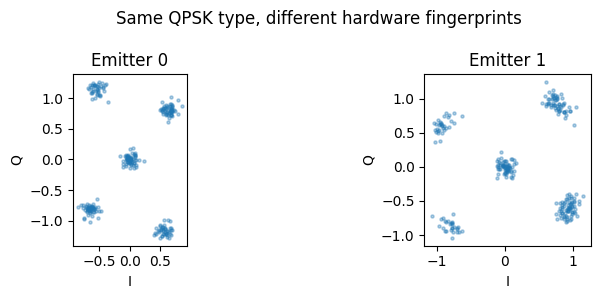

In [3]:
train_iq, train_labels = make_dataset(emitters, TRAIN_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 1)
test_iq, test_labels = make_dataset(emitters, TEST_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 2)
print(f'train: {train_iq.shape}, test: {test_iq.shape}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for emitter_id, ax in enumerate(axes):
    sample = train_iq[np.flatnonzero(train_labels == emitter_id)[0]]
    ax.scatter(sample.real, sample.imag, s=5, alpha=.35)
    ax.set(title=f'Emitter {emitter_id}', xlabel='I', ylabel='Q', aspect='equal')
fig.suptitle('Same QPSK type, different hardware fingerprints'); fig.tight_layout()

### Dataset and constellation view

`make_dataset` generates independent train and test payloads, applies each emitter's fixed impairments, adds capture nuisance variation and AWGN, and normalizes burst power. The resulting shapes are `(1600, 256)` and `(480, 256)`. The two constellation examples use the same QPSK modulation, but their point clouds are stretched, rotated, and blurred differently by the simulated hardware. A classifier can exploit those systematic differences.

## Matched model comparison

Both models use three stride-2 convolutions with kernel sizes 7, 5, and 5, followed by temporal summary statistics and the same embedding size. The real model treats I and Q as two channels and uses BatchNorm plus ReLU. The complex model keeps complex activations, uses covariance-whitening complex batch normalization and modReLU, and starts with a widely-linear convolution:

```text
y = W * x + V * conj(x)
```

The conjugate branch matters because differential IQ imbalance has this same form. Native PyTorch complex parameters are optimized through conjugate Wirtinger derivatives when `loss.backward()` is called. Complex parameters count as two real scalars when comparing capacity.

In [4]:
real_model = EmitterClassifier(RealEncoder(EMBEDDING_DIM), EMBEDDING_DIM, NUM_EMITTERS)
complex_model = EmitterClassifier(ComplexEncoder(EMBEDDING_DIM), EMBEDDING_DIM, NUM_EMITTERS)
pd.DataFrame([
    {'model': 'real', 'real scalar parameters': real_scalar_parameters(real_model)},
    {'model': 'complex', 'real scalar parameters': real_scalar_parameters(complex_model)},
] )

,model,real scalar parameters
0,real,34476
1,complex,34964


### Parameter comparison

The real CNN has 34,476 real scalars and the complex CNN has 34,964, a difference of 488 or about 1.4%. They are therefore closely parameter-matched and share the same depth, downsampling schedule, embedding dimension, and classifier. They are not identical function classes: the real model has wider real channels, while the complex model spends parameters on paired real/imaginary weights, complex whitening, and the conjugate branch.

### Supervised training

Both classifiers use the same Adam learning rate, batch size, epoch count, and cross-entropy objective. The printed `loss` is average training loss; `test_acc` is classification accuracy on the held-out payloads after each epoch. Comparing training loss is important: a high final loss would indicate that a model failed to fit before any generalization comparison is meaningful.

In [5]:
print('Real CNN')
real_history = train_classifier(real_model, train_iq, train_labels, test_iq, test_labels, device, EPOCHS, BATCH_SIZE)

Real CNN


epoch  1: loss=1.228, test_acc=0.537
epoch  2: loss=0.742, test_acc=0.958
epoch  3: loss=0.393, test_acc=0.844
epoch  4: loss=0.220, test_acc=1.000
epoch  5: loss=0.115, test_acc=1.000
epoch  6: loss=0.069, test_acc=1.000
epoch  7: loss=0.047, test_acc=1.000
epoch  8: loss=0.037, test_acc=1.000
epoch  9: loss=0.025, test_acc=1.000


epoch 10: loss=0.019, test_acc=1.000
epoch 11: loss=0.013, test_acc=1.000
epoch 12: loss=0.014, test_acc=1.000
epoch 13: loss=0.010, test_acc=1.000
epoch 14: loss=0.009, test_acc=1.000
epoch 15: loss=0.009, test_acc=1.000
epoch 16: loss=0.006, test_acc=1.000
epoch 17: loss=0.005, test_acc=1.000


In [6]:
print('Complex CNN')
complex_history = train_classifier(complex_model, train_iq, train_labels, test_iq, test_labels, device, EPOCHS, BATCH_SIZE)

Complex CNN


epoch  1: loss=1.370, test_acc=0.427


epoch  2: loss=1.147, test_acc=0.742


epoch  3: loss=0.936, test_acc=0.908


epoch  4: loss=0.750, test_acc=0.990


...

epoch 13: loss=0.108, test_acc=0.998


epoch 14: loss=0.073, test_acc=0.998


epoch 15: loss=0.070, test_acc=0.998


epoch 16: loss=0.049, test_acc=0.998


epoch 17: loss=0.040, test_acc=0.998


### Training result

The real model converges faster, reaching perfect test accuracy by epoch 4 and a final training loss near 0.005. The complex model improves more gradually but reaches 0.998 test accuracy and a final loss near 0.040. This is a major change from the original complex architecture, whose loss remained near 0.766 and accuracy near 0.72. Correct differential IQ imbalance, conjugate-aware filtering, complex whitening, and an active modReLU together remove that underfitting failure. Because those changes were applied together, this run does not identify the contribution of each one.

,model,accuracy,worst emitter
0,real,1.000,1.000
1,complex,0.998,0.992


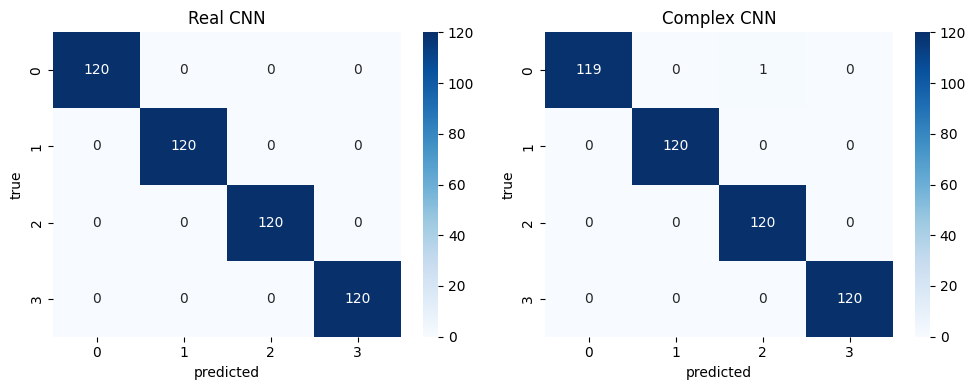

In [7]:
models = {'real': real_model, 'complex': complex_model}
results = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    predicted = predictions(model, test_iq, device)
    matrix, per_emitter = emitter_metrics(test_labels, predicted)
    results.append({'model': name, 'accuracy': (predicted == test_labels).mean(), 'worst emitter': per_emitter.min()})
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set(title=f'{name.title()} CNN', xlabel='predicted', ylabel='true')
fig.tight_layout()
pd.DataFrame(results).round(3)

### Closed-set result

The real CNN correctly classifies all 480 test captures. The complex CNN misses only one capture, giving 0.998 overall accuracy and 0.992 accuracy for its hardest emitter. The nearly diagonal confusion matrices show that both models recover emitter-specific impairment patterns rather than collapsing two emitters into one class. At this ceiling, the 0.002 difference is not practically meaningful without repeated seeds and confidence intervals.

## Robustness to noise

The trained models are evaluated at new SNRs without retraining.

model,complex,real
SNR (dB),,
6,0.965,0.98
10,0.995,1.00
14,0.995,1.00
18,1.000,1.00
22,1.000,1.00


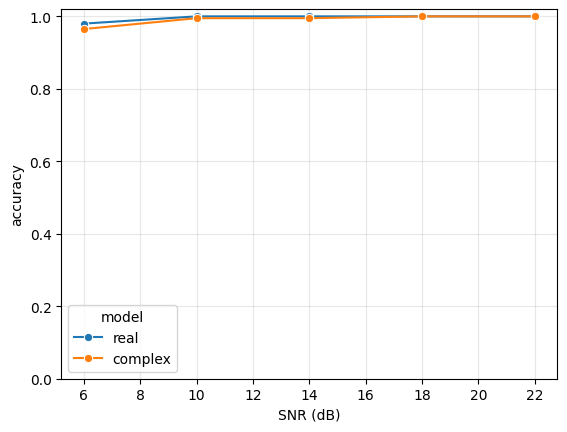

In [8]:
snr_rows = []
for snr in (6, 10, 14, 18, 22):
    sweep_iq, sweep_labels = make_dataset(emitters, 50, IQ_LENGTH, snr, SEED + 100 + snr)
    for name, model in models.items():
        score = (predictions(model, sweep_iq, device) == sweep_labels).mean()
        snr_rows.append({'SNR (dB)': snr, 'accuracy': score, 'model': name})
snr_results = pd.DataFrame(snr_rows)
sns.lineplot(snr_results, x='SNR (dB)', y='accuracy', hue='model', marker='o'); plt.ylim(0, 1.02); plt.grid(alpha=.3)
snr_results.pivot(index='SNR (dB)', columns='model', values='accuracy').round(3)

### Interpreting the SNR sweep

Each point uses newly generated captures at the stated SNR; neither model is retrained. The table gives the exact values behind the plot. Accuracy should rise as noise stops masking the relatively small hardware distortions. Differences at a single SNR should be treated cautiously because each point is one generated sample set rather than an average over repeated datasets.

## Learned embeddings

The next cell extracts each encoder's 64-dimensional representation and projects it to two dimensions with PCA. Compact, separated color groups indicate that captures from the same emitter occupy similar regions. PCA is only a visualization: overlap in two dimensions does not necessarily imply overlap in the full embedding space.

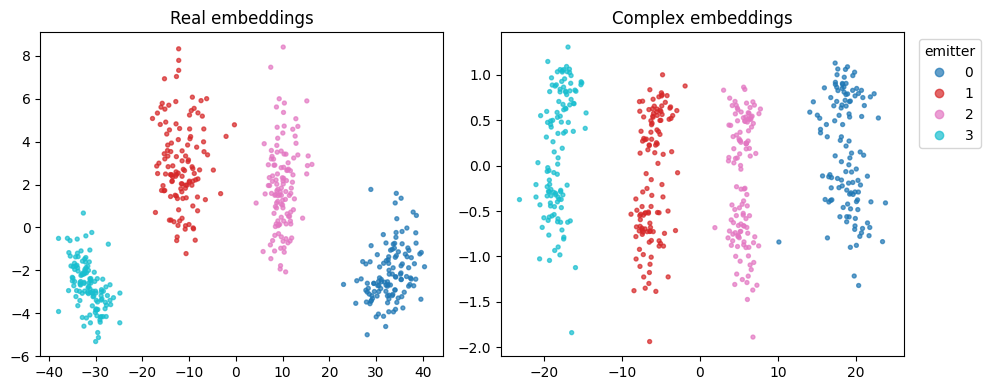

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    points = PCA(2).fit_transform(embeddings(model, test_iq, device))
    scatter = ax.scatter(points[:, 0], points[:, 1], c=test_labels, s=8, cmap='tab10', alpha=.7)
    ax.set_title(f'{name.title()} embeddings')
axes[1].legend(*scatter.legend_elements(), title='emitter', bbox_to_anchor=(1.02, 1)); fig.tight_layout()

### Embedding result

Both encoders form emitter-dependent structure consistent with their near-perfect classification scores. The real embedding appears especially separated in this PCA view, while the complex representation uses a different geometry. The classifier evaluates the full 64-dimensional vectors, so this plot should be used as a qualitative diagnostic rather than a ranking metric.

## Bonus: unknown emitters

This is intentionally only one open-set check. Two new emitters were never used for training. Higher cosine similarity to a known emitter prototype means 'known'; AUROC measures how well that separates enrolled from new emitters.

In [10]:
unknown_emitters = make_emitters(2, SEED + 999)
unknown_iq, _ = make_dataset(unknown_emitters, TEST_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 1000)
open_rows = []
for name, model in models.items():
    score = open_set_auroc(
        embeddings(model, train_iq, device), train_labels,
        embeddings(model, test_iq, device), embeddings(model, unknown_iq, device),
    )
    open_rows.append({'model': name, 'unknown-emitter AUROC': score})
pd.DataFrame(open_rows).round(3)

,model,unknown-emitter AUROC
0,real,0.656
1,complex,0.699


### Unknown-emitter result

The complex embeddings obtain AUROC 0.702 versus 0.656 for the real embeddings in this run. An AUROC of 0.5 is random ordering and 1.0 is perfect separation, so both contain some novelty information but remain far from a reliable open-set detector. The complex advantage here is suggestive only: there are just two synthetic unknown emitters, one seed, and a simple nearest-prototype cosine score.

## Takeaway

Emitter identification is possible even when every device sends the same modulation. With a corrected differential IQ impairment and a complex architecture matched to its conjugate structure, both models achieve essentially perfect closed-set accuracy. The result supports complex-valued processing as a viable IQ representation, but does not prove it is superior: this is one synthetic seed at near-ceiling performance. The SNR sweep tests robustness, while the unknown-emitter result is a small diagnostic rather than a full open-set system. Multi-seed runs and one-change-at-a-time ablations are needed for stronger conclusions.